In [1]:
from pathlib import Path
import sys

# Get the absolute path of the parent directory
parent_dir = str(Path(".").resolve().parent)

# Add it to the system path
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms.v2 as transforms_v2
import pydicom as dicom
import pandas as pd
import numpy as np
import optuna
from sklearn.model_selection import train_test_split
import skimage
import scipy

import cbis
import metrics
import unet
import albumentations as A

import matplotlib.pyplot as plt

In [2]:
device = "cpu"
random_state=0
data_root_filepath = "/run/media/gianluca/EXTERNAL_US/CBIS-DDSM" # path to the root folder of the data
batch_size=4

# defining transforms to augment data
"""
transforms = transforms_v2.Compose(
    [
        transforms_v2.RandomHorizontalFlip(),
        transforms_v2.RandomVerticalFlip(),
        transforms_v2.RandomRotation(degrees=(-270, 270))
    ]
)
"""
transforms = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Rotate(limit=270, p=1.0)
])

# keeping only MLO and masses
df = pd.read_csv(f"{data_root_filepath}/lesions.csv")
df = df[
    (df["image view"] == "MLO") & 
    (df["kind"] == "Mass")
].head(30)

# dividing data in test and train data
df_train_val, df_test = train_test_split(df, test_size=0.1,random_state=random_state)

# divide data in training and validation set
df_train, df_val = train_test_split(df_train_val, test_size=0.22, random_state=random_state)

trainval_data = cbis.CBIS_Dataset(data_root_filepath, df_train_val, transform=transforms)
test_data = cbis.CBIS_Dataset(data_root_filepath, df_test)

trainval_dataloader = DataLoader(
        dataset=trainval_data,
        batch_size=batch_size,
        num_workers=4,
        pin_memory=True,
        persistent_workers=True
    )
test_dataloader = DataLoader(
    dataset=test_data,
    batch_size=batch_size,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

model = unet.UNet(n_class=2)
checkpoint = torch.load(
    "/home/gianluca/Desktop/BestModelDice/final_model/checkpoints/checkpoint_23.pth", 
    weights_only=True, 
    map_location=torch.device('cpu')
)
model.load_state_dict(checkpoint['model_state_dict'])

loss_fn = metrics.DiceLoss()

In [12]:
it = iter(trainval_dataloader)

In [13]:
X, y = next(it)
logits = model(X)
pred_probs = torch.softmax(logits, dim=1)

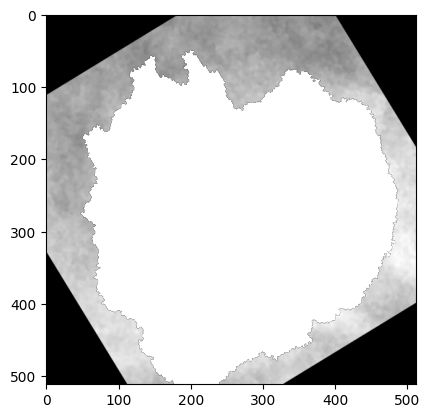

In [14]:
i = 0
plt.imshow(X[i,0], cmap="gray")
plt.imshow(y[i,1], cmap="gray", alpha=(y[0,1] > 0).float())

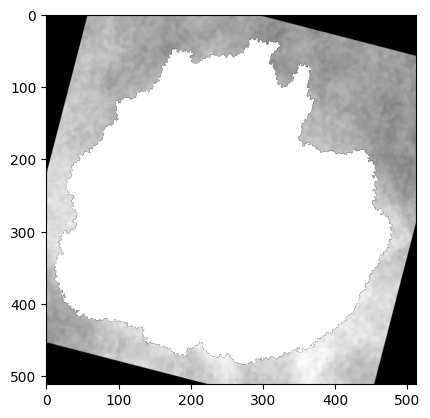

In [10]:
i = 0
plt.imshow(X[i,0], cmap="gray")
plt.imshow(y[i,1], cmap="gray", alpha=(y[0,1] > 0).float())

In [ ]:
plt.imshow(pred_probs.detach()[0,1])

In [22]:
loss_fn = metrics.JaccardLoss()
loss = loss_fn(y.float(), pred_probs).item()
print(loss)

0.4943016767501831
